<a href="https://colab.research.google.com/github/sYanXO/Volatility-Regime-Analysis/blob/main/quant_research_01_volatility_regimes_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas yfinance numpy matplotlib

In [ ]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data  = yf.download("RELIANCE.NS", start = "2016-01-01", end = "2026-01-01")

/tmp/ipykernel_315/608865123.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data  = yf.download("RELIANCE.NS", start = "2016-01-01", end = "2026-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2016-01-01,220.010025,220.779245,218.460736,218.807420,5416562
2016-01-04,215.665497,219.674151,213.802010,217.767329,30170947
2016-01-05,217.799835,218.850751,216.033868,216.748919,14946239
2016-01-06,223.661148,225.004593,216.770593,218.330716,26759864
2016-01-07,219.554993,222.751076,218.428239,221.245123,19739943


In [ ]:
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2025-12-24,1558.199951,1575.699951,1553.599976,1572.699951,8815745
2025-12-26,1559.199951,1561.000000,1554.300049,1554.699951,2311495
2025-12-29,1545.599976,1558.099976,1543.599976,1554.900024,5972105
2025-12-30,1539.800049,1553.599976,1537.800049,1547.000000,8815884
2025-12-31,1570.400024,1577.000000,1541.000000,1541.000000,5771830


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2470 entries, 2016-01-01 to 2025-12-31
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   2470 non-null   float64
 1   (High, RELIANCE.NS)    2470 non-null   float64
 2   (Low, RELIANCE.NS)     2470 non-null   float64
 3   (Open, RELIANCE.NS)    2470 non-null   float64
 4   (Volume, RELIANCE.NS)  2470 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 115.8 KB


In [ ]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
count,2470.000000,2470.000000,2470.000000,2470.000000,2.470000e+03
mean,849.517734,858.352873,841.280258,849.979120,1.800725e+07
std,421.581592,424.949616,418.373779,421.694252,1.360903e+07
min,196.434814,202.361125,192.436994,198.915834,0.000000e+00
25%,440.329155,446.678403,432.046062,439.201579,1.022680e+07
50%,922.075134,936.431798,908.279451,925.351127,1.415321e+07
75%,1195.498657,1208.659836,1185.116938,1196.922810,2.064505e+07
max,1589.138062,1596.980044,1573.851280,1592.662006,1.426834e+08


In [ ]:
data["Daily Returns"] = data["Close"].pct_change()
data["Daily Returns %"] = (data["Daily Returns"]*100).round(3)
data.tail()

Price,Close,High,Low,Open,Volume,Daily Returns,Daily Returns %
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,
Date,,,,,,,
2025-12-24,1558.199951,1575.699951,1553.599976,1572.699951,8815745,-0.007958,-0.796
2025-12-26,1559.199951,1561.000000,1554.300049,1554.699951,2311495,0.000642,0.064
2025-12-29,1545.599976,1558.099976,1543.599976,1554.900024,5972105,-0.008722,-0.872
2025-12-30,1539.800049,1553.599976,1537.800049,1547.000000,8815884,-0.003753,-0.375
2025-12-31,1570.400024,1577.000000,1541.000000,1541.000000,5771830,0.019873,1.987


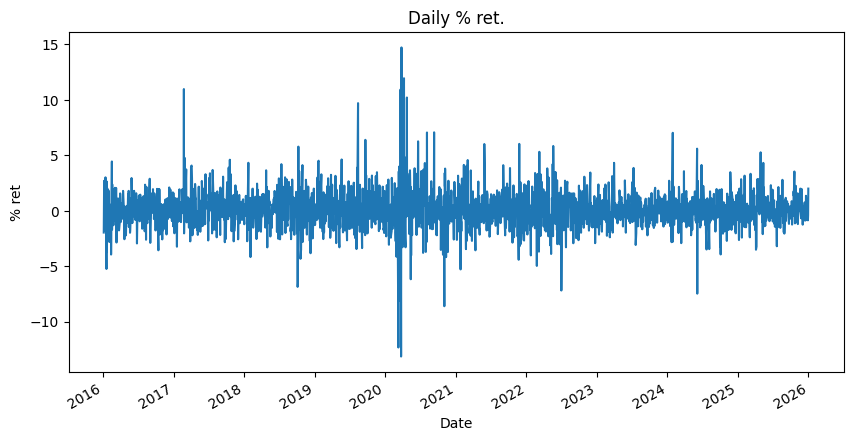

In [ ]:
data["Daily Returns %"].plot(figsize=(10,5))
plt.title("Daily % ret.")
plt.ylabel("% ret")
plt.show()

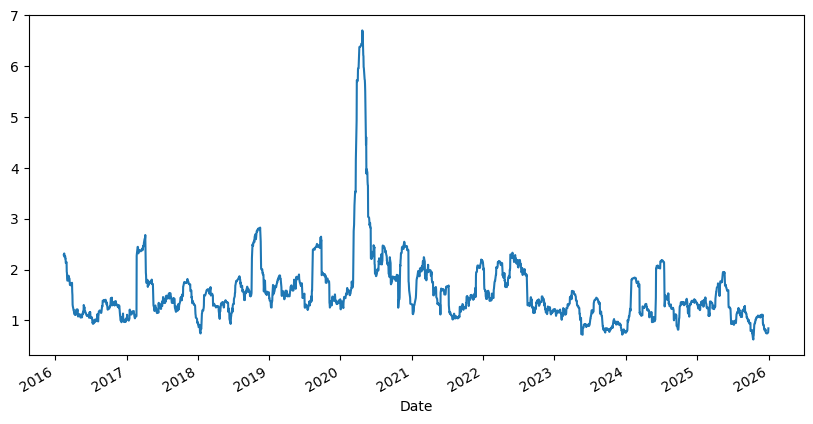

In [ ]:
data["Volatility"] = data["Daily Returns"].rolling(30).std()*100
data["Volatility"].plot(figsize=(10,5))
plt.show()

Covid happened hence the spikes. daily volume spiked a lot.

Noticing a specific trend around the 2.5 zone. test if money cn be made

In [ ]:
highvol = data[data["Volatility"] > 2.5]
lowvol = data[data["Volatility"] <= 2.5]


print("High volume avg return", highvol["Daily Returns"].mean()*100)
print("Low volume avg return", lowvol["Daily Returns"].mean()*100)

High volume avg return 0.565805150542051
Low volume avg return 0.0802852883280204


HIgh volume return is almost 7x that of low volume


Issue exisst cuz we can trade tomorrow by knowing today's volatility...that has been the whole strategy so far

In [ ]:
data["next day return"] = data["Daily Returns"].shift(-1)
highvol = data[data["Volatility"] > 2.5]
lowvol = data[data["Volatility"] <= 2.5]


print("High next day volume avg return", highvol["next day return"].mean()*100)
print("Low next day volume avg return", lowvol["next day return"].mean()*100)


High next day volume avg return 0.5382388873730574
Low next day volume avg return 0.07956787872909932


Checking now for absolute returns

In [ ]:
data["abs next"] = data["next day return"].abs()
highvol = data[data["Volatility"] > 2.5]
lowvol = data[data["Volatility"] <= 2.5]
print(highvol["abs next"].mean()*100)
print(lowvol["abs next"].mean()*100)

2.5682052737902072
1.1213148570483344


The analysis suggests volatility clustering: high-volatility periods (Volatility > 2.5) are followed by significantly larger next-day price movements, with the average absolute return increasing from ~1.12% in low-volatility regimes to ~2.56% in high-volatility regimes.